In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/hospital_performance_hpi.csv")

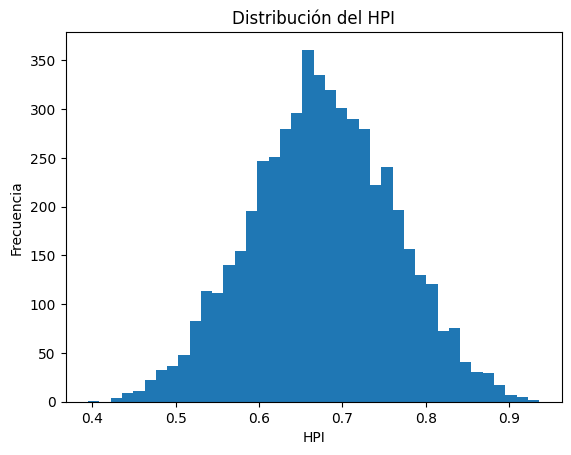

count    5274.000000
mean        0.675755
std         0.085830
min         0.395000
25%         0.618000
50%         0.675000
75%         0.735000
max         0.936000
Name: hpi, dtype: float64


In [2]:
plt.hist(df["hpi"], bins=40)
plt.title("Distribución del HPI")
plt.xlabel("HPI")
plt.ylabel("Frecuencia")
plt.show()

print(df["hpi"].describe())

In [3]:
df.groupby("performance_category")["hpi"].agg(["count","mean","min","max"])

,count,mean,min,max
performance_category,,,,
High Performance,1059,0.795892,0.750,0.936
Low Performance,104,0.473865,0.395,0.500
Medium Performance,4111,0.649914,0.500,0.750


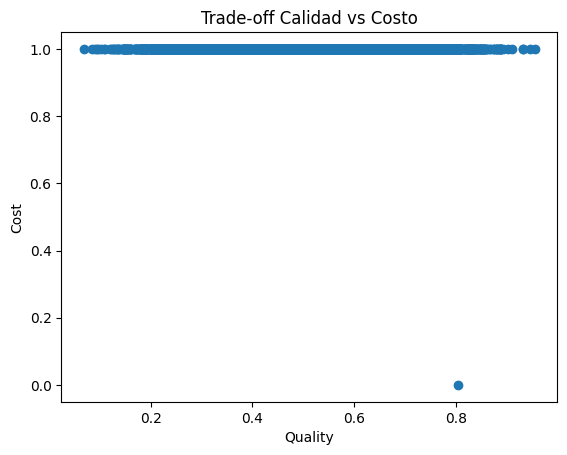

In [4]:
plt.scatter(df["quality_score"], df["cost_score"])
plt.xlabel("Quality")
plt.ylabel("Cost")
plt.title("Trade-off Calidad vs Costo")
plt.show()

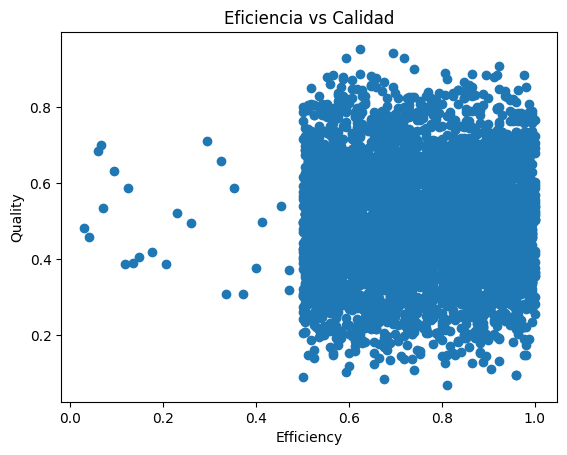

In [5]:
plt.scatter(df["efficiency_score"], df["quality_score"])
plt.xlabel("Efficiency")
plt.ylabel("Quality")
plt.title("Eficiencia vs Calidad")
plt.show()

In [8]:
optimal = df[
    (df["quality_score"] > df["quality_score"].quantile(0.75)) &
    (df["cost_score"] > df["cost_score"].quantile(0.75))
]

optimal.head()

,hospital_id,hospital_name,city,province,quality_score,efficiency_score,cost_score,hpi,performance_category


In [9]:
inefficient = df[
    (df["quality_score"] < df["quality_score"].quantile(0.25)) &
    (df["cost_score"] < df["cost_score"].quantile(0.25))
]

inefficient.head()

,hospital_id,hospital_name,city,province,quality_score,efficiency_score,cost_score,hpi,performance_category


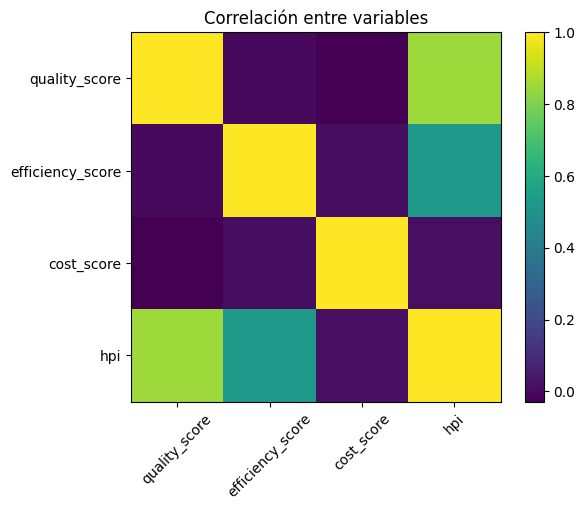

In [10]:
corr = df[[
    "quality_score",
    "efficiency_score",
    "cost_score",
    "hpi"
]].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlación entre variables")
plt.show()

In [11]:
def segment(row):
    if row["quality_score"] > 0.7 and row["cost_score"] > 0.7:
        return "High Quality - Low Cost"
    elif row["quality_score"] > 0.7:
        return "High Quality - High Cost"
    elif row["efficiency_score"] > 0.7:
        return "Efficient"
    else:
        return "Low Performance"

df["segment"] = df.apply(segment, axis=1)

In [12]:
df["segment"].value_counts()

segment
Efficient                   2877
Low Performance             1934
High Quality - Low Cost      462
High Quality - High Cost       1
Name: count, dtype: int64

In [16]:
df1 = df[~(df['segment']=='High Quality - High Cost')].copy()

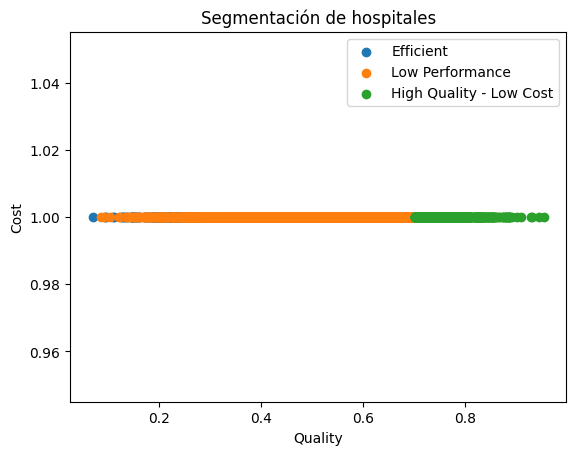

In [17]:
for seg in df1["segment"].unique():
    subset = df1[df1["segment"] == seg]
    plt.scatter(subset["quality_score"], subset["cost_score"], label=seg)

plt.legend()
plt.xlabel("Quality")
plt.ylabel("Cost")
plt.title("Segmentación de hospitales")
plt.show()

In [20]:
top10 = df.sort_values("hpi", ascending=False).head(10)

top10[[
    "hospital_name",
    "quality_score",
    "efficiency_score",
    "cost_score",
    "hpi"
]]

,hospital_name,quality_score,efficiency_score,cost_score,hpi
124,Hospital_MCJVO,0.886,0.976,1.0,0.936
3936,Hospital_XFXJR,0.910,0.924,1.0,0.932
136,Hospital_PYAWW,0.854,0.982,1.0,0.922
1884,Hospital_GDJBX,0.886,0.918,1.0,0.918
2181,Hospital_YWRGN,0.879,0.912,1.0,0.913
4239,Hospital_MROCT,0.847,0.965,1.0,0.913
112,Hospital_TUVOG,0.886,0.894,1.0,0.911
2190,Hospital_HMYBF,0.888,0.865,1.0,0.904
1829,Hospital_SDZSB,0.842,0.935,1.0,0.902
960,Hospital_AJUWA,0.810,0.988,1.0,0.901
